<a href="https://colab.research.google.com/github/SotaYoshida/Lecture_DataScience/blob/master/Python_chapter8_ArtificialNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 機械学習: 3層ニューラルネットワークによる回帰

最も単純な、入力層・隠れ層・出力層からなるニューラルネットワークを使って、データから尤もらしい予測を与える関数を構築してみましょう。

対象とする(疑似)データは、多項式回帰の際に用いたデータと同じsin関数＋ノイズで生成することにします。


* すすんだ注: このノートブックでは「ニューラルネットワークをPythonで表現してみる」ことに重きをおくため、使用するデータを訓練データ,検証データ,テストデータに分けることはせず、データは全てニューラルネットワークの訓練データとして使うこととします。
授業で説明するとおり、一般に[教師あり学習]の文脈でニューラルネットワークを考える際は、本来データを上の様に複数用途に分けながら、モデル選択を行ったり、汎化性能の評価に使ったりします。

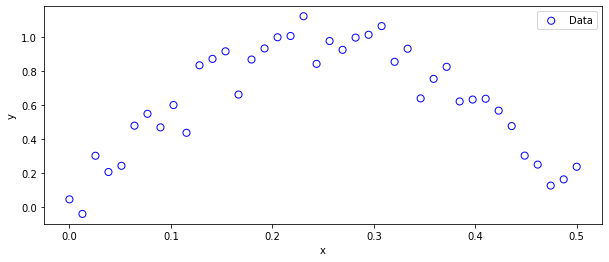

In [11]:
import numpy as np
def create_toy_data(sample_size, std):
    np.random.seed(1234) #毎回同じデータになるように乱数の種を固定しておく 
    x = np.linspace(0, 0.5, sample_size)
    t = np.sin(2*np.pi*x) + np.random.normal(scale=std, size=x.shape)                                                                                                                 
    return x, t
xt,yt = create_toy_data(40,1.e-2) 

###グラフにしてみる
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.scatter(xt, yt, facecolor="none", edgecolor="b", s=50, label="Data")
ax.legend()
plt.show()
plt.close()

ではいくつか必要な関数を適宜定義しながら進めていきましょう。

*注: 以下のコードは入力・出力ともに1次元かつ、決まったニューラルネットワーク構造の場合に対して書かれているため、naiveに2層以上の隠れ層を持つニューラルネットワークに拡張するのはstraightfowardではなく、また効率的ではありません。

In [12]:
nhl = 16 ## 隠れ層のノードの数を指定 これを増やすほどニューラルネットワークの表現能力が上がる一方、データに過適合しやすくなる(例外あり)

In [13]:
#重み行列W,V(今はベクトル)と、隠れ層でのバイアスbs,出力層でのバイアスを正規乱数で初期化
np.random.seed(1234)  #結果が実行ごとに同じになるよう乱数を固定(バグを見つけやすくする)
W = np.array([ np.random.normal() for i in range(nhl)])
V = np.array([ np.random.normal() for i in range(nhl)])
bs = np.array([np.random.normal() for i in range(nhl)])
b0 = np.random.normal()

隠れ層で作用させる活性化関数を定義しておきましょう。

In [14]:
#シグモイド関数: 活性化関数の一つ
def sigmoid(z):
    return 1.0/(1.0+np.exp(-z))

最適化したい量(データとモデルの齟齬を表す量)を目的関数(target function)やloss functionなどと呼びます。(以下でもそれに倣う)

以下では、データとANNのアウトプットの二乗誤差を目的関数として定めることにします。

In [15]:
def mse(yt,ynn):
    return np.dot(yt-ynn,yt-ynn)

In [16]:
### データとANNの出力間の二乗誤差を計算する関数を作っておく。
def calc_tloss(x,y,W,V,bs,b0,acf):
    nhl = len(W)
    s=0.0
    for i in range(len(x)):
        s += mse(y,np.dot(V, acf(W*x[i]+bs)) + b0)
    return s

上ではcalc_tlossの引数にacfという変数を指定し、acfにsigmoidを指定しました。この様にしておくと、sigmoid関数以外の活性化関数を使う際にも、上のcalc_tloss関数が使いまわせますね。



####データの下処理

機械学習などの分析では、データの値を中心0,分散1に変換して扱うのが基本です。

このことを、データの標準化と呼びます。



In [17]:
ymean = np.mean(yt)
ystd = np.std(yt)
ny = (np.array(yt)-ymean)/ ystd #それぞれのデータを平均をひいて標準偏差で割る

なぜ標準化が必要なのかは、今のような1次元入力データの場合よりもむしろ多変数を扱う際を考えてみるとわかります。

変数ごとに標準的なスケールが違う値を扱う場合、スケールの大きな量に学習が引っ張られる、ということが起こりえます。

たとえば目的関数を[体重と身長、それぞれについての二乗誤差の和]とする場合、
データが50kg、ニューラルネットワークの予測が55kgで10%違っていても、二乗誤差の値は25ですが.
身長が180cm vs 198cmと10%違っていたら、二乗誤差の値は324となります。
したがって、目的関数は身長の予測精度により強く依存することになり、身長をより重視する(きちんと再現する)方向へ、ニューラルネットワークの学習が引っ張られてしまいます。

もちろん、身長をより高い精度で推測したいニューラルネットワークを構築したいなら話は別ですが、
特定の値を特別視しない(全ての量を平等に扱う)のなら、標準化が必須です。

In [18]:
acf = sigmoid #sigmoid関数をacfという名前で使う

さて、初期値W,V,bs,b0と活性化関数にsigmoidを選んだニューラルネットワークとデータの値の二乗誤差は...

In [19]:
print("initial mse=",calc_tloss(xt,ny,W,V,bs,b0,acf))

initial mse= 12536.463614480857


データ1個あたり、ニューラルネットワークとデータ値との間にどれくらい誤差があるかというと...

In [21]:
print("データ1個あたり=", np.sqrt(calc_tloss(xt,ny,W,V,bs,b0,acf)/len(xt))) #データ1個あたりどれほど誤差*があるか *標準化された誤差

データ1個あたり= 17.703434422789876


ランダムに生成した重み(W,V)やバイアス項(bs,b0)では、まだニューラルネットワークは訓練がなされていないデタラメな関数なので、図にプロットしてみると...


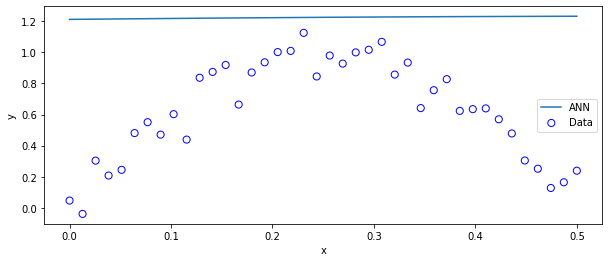

In [22]:
xp = np.linspace(0.0,0.5,300)
yp = np.array([np.dot(V, sigmoid(W*xp[i]+bs)) for i in range(len(xp))])

fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.scatter(xt, yt, facecolor="none", edgecolor="b", s=50, label="Data") 
ax.plot(xp,yp*ystd+ymean,label="ANN") #ニューラルネットワークの予測ypは、"標準化された"yの値に従って学習されているので、元のスケールに戻さないといけない。
ax.legend()
plt.show(); plt.close()

当然ですが、全然だめですね。

状況を改善するためにニューラルネットワークのパラメータを徐々に更新(学習)していきましょう。

そのためには、まず勾配を計算する関数を用意しておきます。

loss functionを$f$と書くことにすると、必要な勾配は4種類で
$\frac{\partial f}{\partial W}, \frac{\partial f}{\partial V}, \frac{\partial f}{\partial b}, \frac{\partial f}{\partial b_0}$です。  
プログラムではそれぞれ```dw,dv,dbs,db0```とでも名前をつけることにして、勾配を返り値として与える関数を定義します。

以下では、勾配降下法, Adamの2通りの最適化手法を用いてパラメータを更新することとします。

### 勾配降下法

勾配降下法とは、目的関数を微分した勾配の値のみを使ってパラメータを更新する方法です。

たとえば,重み$W$の$i$番目を更新する際には、

$W/i := W_i - \eta \frac{\partial f}{\partial W_i}$

とします。($f$は目的関数で、$\eta$は学習率(パラメータ更新のスケールを決めるパラメータ)です。)

In [23]:
def calc_der(x,y,W,V,bs,b0,acf,acfder):
    dw =  np.array([0.0 for i in range(nhl)])
    dv =  np.array([0.0 for i in range(nhl)])
    dbs = np.array([0.0 for i in range(nhl)])
    db0 = 0.0
    #以下の勾配の計算は、目的関数が二乗誤差かつ全データでの勾配の和を使用する場合にのみ正しい
    for i in range(len(x)):
        g = np.dot(V, acf(W*x[i]+bs) ) + b0 - y[i]
        db0 += 2.0 * g
        for jth in range(nhl):                    
            dv[jth]  += 2.0 * g * acf(W[jth]*x[i]+bs[jth])
            dw[jth]  += 2.0 * g * V[jth] * acfder(W[jth]*x[i]+bs[jth]) *x[i]
            dbs[jth] += 2.0 * g * V[jth] * acfder(W[jth]*x[i]+bs[jth])
    return dw, dv, dbs, db0

#シグモイド関数の微分: 勾配の計算を具体的に求めるのに使う
def sigder(z):
    return np.exp(-z)/ ((1.0+np.exp(-z))**2)

さてW,V,bs,b0の初期値での勾配の値は

In [25]:
acf = sigmoid
acfder = sigder #sigmoid関数の微分sigderをacfderという名前で使う
calc_der(xt,ny,W,V,bs,b0,acf,acfder)

(array([  3.69205521,   3.39679629,  10.93859879, -19.7232494 ,
         -2.60321813,  -8.45788164,   1.82175939,   2.66027601,
         17.01949267,  -3.8864526 ,   8.26168647, -12.18529691,
         -2.164157  ,   7.51675857,  -5.05823816,   4.36379354]),
 array([159.32733857, 141.77852164, 160.81605881,  94.18893323,
        101.78729859,  99.20559847, 154.8983132 , 188.82117119,
        108.75972742,  52.81305287, 121.04174924,  29.17861723,
        129.22575039,  42.64018066,  93.1562716 , 105.55835254]),
 array([ 15.37056709,  13.08532768,  48.5904845 , -80.02971635,
        -10.548674  , -34.01508278,   7.73974491,  10.14650359,
         68.81213875, -18.03920728,  34.12858813, -45.46662196,
         -8.98645906,  35.28427426, -20.53760305,  17.64215749]),
 209.14938165821823)

と計算できるようになりました。

In [26]:
def fitGD(x,y,W,V,bs,b0,acf,acfder,nepoch,eta,verbose):
    for i in range(nepoch):
        dw,dv,dbs, db0 = calc_der(x,y,W,V,bs,b0,acf,acfder)
        W = W - eta * dw
        V = V -eta * dv
        bs =  bs -eta * dbs
        b0 = b0 -eta * db0        
        if verbose == 1:
            print(i, "tloss =", calc_tloss(x,y,W,V,bs,b0,acf))
    return W,V,bs,b0,dw,dv,dbs, db0

では実際に上の関数を使って、パラメータの値を更新してみましょう。(nhlの値に依りますが、ちょっぴり計算に時間がかかります)

In [28]:
nepoch = 1000
acf = sigmoid; acfder=sigder
verbose=0
eta = 0.001 #学習率(パラメータ更新のスケールを決めるパラメータ)
W,V,bs,b0,dw,dv,dbs,db0=fitGD(xt,ny,W,V,bs,b0,acf,acfder,nepoch,eta,verbose)

更新された重み・バイアス(W,V,bs,b0)を使って、データとの二乗誤差を計算してみると...

In [31]:
print("mse=",calc_tloss(xt,ny,W,V,bs,b0,acf))

mse= 1609.0107412048626


すると、さっきより小さくはなっていますが、あまり二乗誤差が減っていません。  

実際にplotしてみても

In [32]:
xp = np.linspace(0, 0.5, 500) 
yp = 0.0*xp 
for i in range(len(yp)):
    yp[i] = np.dot(V, sigmoid(W*xp[i]+bs)) + b0 

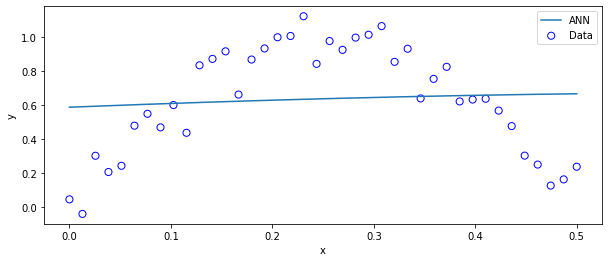

In [34]:
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.scatter(xt, yt, facecolor="none", edgecolor="b", s=50, label="Data")
ax.plot(xp,yp*ystd+ymean,label="ANN") ## ニューラルネットワークの出力は標準化した値に対して学習されていることに注意
ax.legend()
plt.show()
plt.close()

全然学習が進んでいません...(絶望)



In [35]:
np.random.seed(1234)
W = np.array([ np.random.normal() for i in range(nhl)])
V = np.array([ np.random.normal() for i in range(nhl)])
bs = np.array([np.random.normal() for i in range(nhl)])
b0 = np.random.normal()

学習の様子を都度printしてみる(```verbose=1```に設定する)ことにすると

In [36]:
nepoch=20 #20回だけ学習の様子を表示
verbose=1 
print("学習前のloss", calc_tloss(xt,ny,W,V,bs,b0,acf))
#学習
W,V,bs,b0,dw,dv,dbs,db0=fitGD(xt,ny,W,V,bs,b0,acf,acfder,nepoch,eta,verbose)

学習前のloss 12536.463614480857
0 tloss = 3934.4641744255987
1 tloss = 2101.1694170607348
2 tloss = 1707.5389479920295
3 tloss = 1623.1217902492797
4 tloss = 1605.0133958400577
5 tloss = 1601.113136840599
6 tloss = 1600.2643545497856
7 tloss = 1600.0758259561371
8 tloss = 1600.032607171433
9 tloss = 1600.0225322303572
10 tloss = 1600.0205704597195
11 tloss = 1600.0208640820351
12 tloss = 1600.0219220567874
13 tloss = 1600.0233141649105
14 tloss = 1600.0248965115254
15 tloss = 1600.0266140632475
16 tloss = 1600.028443583118
17 tloss = 1600.030374548258
18 tloss = 1600.0324018875938
19 tloss = 1600.0345229589823


ほとんど学習が進んでいない事がわかります。

原因として考えられるのは

* 最適化手法や学習率の設定が適切でない
* 初期値が悪い

などがあります。

勾配降下法は、最もシンプルな勾配を使った最適化手法ですが、学習の途中で勾配がほとんど0になってしまって(勾配消失ともいう)、学習が進まなくなってしまう、といったことがよく起こります。  

「勾配が小さいなら学習率を大きくすればええんとちゃいまんの...？」と思うかもしれませんが、学習率を単純に大きくしてしまうと、明後日の方向にパラメータを更新するせいで目的関数が発散してしまいます。(eta=0.1などとして試してみてください)

勾配降下法を改良した、データを部分的に使う確率的勾配降下法(Stochastic Gradient Descent; SGD)は現在もよく使われています。

以下では、Adamと呼ばれる別の最適化手法を試してみましょう。

#### Adam

Adamは、勾配降下法の様にその都度の勾配の情報だけを使うのではなく、
以前の勾配の情報も有効活用する手法です。

Adamは2014年に提唱された比較的新しい手法で、以降の機械学習の論文では、Adamが最もよく使われています。(*最も"良い"という意味では必ずしもありません)

In [37]:
def updateAdam(A,mt,vt,i,beta1,beta2,eps):
    mhat = mt / (1.0-beta1**(i+1))
    vhat = vt / (1.0-beta2**(i+1))
    return mhat / (np.sqrt( vhat )+eps)

def fitAdam(x,y,W,V,bs,b0,acf,acfder,nepoch,eta,verbose):
    #新たに必要なものを定義しておく。
    mt_w = np.array([0.0 for i in range(len(W))])
    mt_v = np.array([0.0 for i in range(len(V))])
    mt_bs = np.array([0.0 for i in range(len(bs))])
    mt_b0 = 0.0
    vt_w = np.array([0.0 for i in range(len(W))])
    vt_v = np.array([0.0 for i in range(len(V))])
    vt_bs = np.array([0.0 for i in range(len(bs))])
    vt_b0 = 0.0
    #########
    beta1 = 0.9
    beta2 = 0.999
    eps = 1.e-8
    #########
    for i in range(nepoch):
        dw,dv,dbs, db0 = calc_der(x,y,W,V,bs,b0,acf,acfder)   ### 勾配を計算するところまでは同じ。
        # mt と vtたちの更新 ベクトルをブロードキャストで更新していることに注意
#        mt_w = beta1 * mt_w + (1.0-beta1)*dw
#        vt_w = beta2 * vt_w + (1.0-beta2)*(dw**2)
#        mt_v = beta1 * mt_v + (1.0-beta1)*dv
#        vt_v = beta2 * vt_v + (1.0-beta2)*(dv**2)
#        mt_bs = beta1 * mt_bs + (1.0-beta1)*dbs
#        vt_bs = beta2 * vt_bs + (1.0-beta2)*(dbs**2)
        for jth in range(len(W)):
            mt_w[jth] = beta1*mt_w[jth] + (1.0-beta1)*dw[jth] ## 
            vt_w[jth] = beta2*vt_w[jth] + (1.0-beta2)*(dw[jth]**2)
        for jth in range(len(V)):
            mt_v[jth] = beta1*mt_v[jth] + (1.0-beta1)*dv[jth]
            vt_v[jth] = beta2*vt_v[jth] + (1.0-beta2)*(dv[jth]**2)
        for jth in range(len(bs)):
            mt_bs[jth] = beta1*mt_bs[jth] + (1.0-beta1)*dbs[jth]
            vt_bs[jth] = beta2*vt_bs[jth] + (1.0-beta2)*(dbs[jth]**2)
        mt_b0 = beta1*mt_b0 + (1.0-beta1)*db0
        vt_b0 = beta2*vt_b0 + (1.0-beta2)*(db0**2)
        ### 重み・バイアスの更新
        W += -eta * updateAdam(W, mt_w,vt_w,i,beta1,beta2,eps)
        V += -eta * updateAdam(V, mt_v,vt_v,i,beta1,beta2,eps)
        bs += -eta * updateAdam(bs,mt_bs,vt_bs,i,beta1,beta2,eps)
        b0 += -eta *  (mt_b0/(1.0-beta1**(i+1))) / ( np.sqrt( vt_b0/ (1.0-beta2**(i+1))) + eps)
        if verbose == 1 and i % 500 == 0:
            print(i, "tloss =", calc_tloss(x,y,W,V,bs,b0,acf))
    return W,V,bs,b0,dw,dv,dbs, db0

それでは重みを初期化して、再び学習をしてみましょう

In [43]:
#np.random.seed(1234)
W = np.array([ np.random.normal() for i in range(nhl)])
V = np.array([ np.random.normal() for i in range(nhl)])
bs = np.array([np.random.normal() for i in range(nhl)])
b0 = np.random.normal()
nepoch=2000
verbose=1
eta = 0.01
acf = sigmoid ; acfder =sigder
print("学習前のloss", calc_tloss(xt,ny,W,V,bs,b0,acf))
W,V,bs,b0,dw,dv,dbs,db0=fitAdam(xt,ny,W,V,bs,b0,acf,acfder,nepoch,eta,verbose)
print("学習後のloss", calc_tloss(xt,ny,W,V,bs,b0,acf))

学習前のloss 3480.5332146339283
0 tloss = 3151.6153129912072
500 tloss = 1620.703203370042
1000 tloss = 2939.5322240602773
1500 tloss = 3053.403755269542
学習後のloss 3056.9257554306746


In [46]:
nnyt = 0.0*xt
for i in range(len(nnyt)):
    nnyt[i] = np.dot(V, sigmoid(W*xt[i]+bs)) + b0 
print(nnyt*ystd+ymean)

[0.02164254 0.09259539 0.16546009 0.23949333 0.31387028 0.38771629
 0.46014265 0.530283   0.5973267  0.66054617 0.71931598 0.77312275
 0.82156593 0.86435084 0.9012757  0.93221489 0.95710065 0.97590517
 0.98862475 0.99526721 0.99584365 0.99036507 0.97884421 0.96130279
 0.93778379 0.90836817 0.87319468 0.83248092 0.78654314 0.73581172
 0.68083917 0.62229804 0.56096693 0.49770464 0.43341442 0.36900185
 0.30533139 0.24318669 0.18323895 0.12602642]


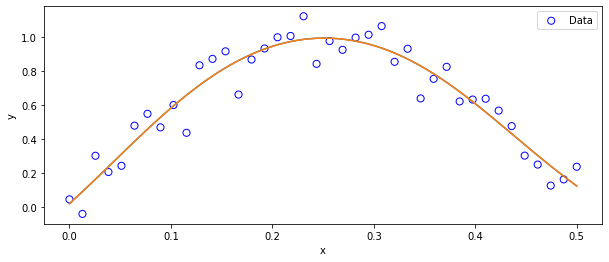

In [47]:
xp = np.linspace(0, 0.5, 500) 
yp = 0.0*xp 
for i in range(len(yp)):
    yp[i] = np.dot(V, sigmoid(W*xp[i]+bs)) + b0 

fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.scatter(xt, yt, facecolor="none", edgecolor="b", s=50, label="Data")
ax.plot(xp,yp*ystd+ymean)
ax.plot(xt,nnyt*ystd+ymean)
ax.legend()
plt.show()
plt.close()

### 最適化手法に関するまとめ

パラメータを更新する方法に

学習がうまく進むかどうかは一般に
* ネットワークの構造(アーキテクチャとも言ったりします)や活性化関数(とその微分)の持つ性質
* 最適化手法や手法内のパラメータ
* 重みやバイアスの初期値

などに強く依存します。また、問題ごとに何が最適なアーキテクチャなのかは、予め分かることはなく、試行錯誤が必要です。

回帰問題における代表的な活性化関数としては
最近の傾向として、sigmoidよりも以下のrelu関数が使われることが多いです。  



In [ ]:
def relu(z):
    return (z > 0)* z   #zが実数値でもnp.arrayでも対応できる表式

def relu_der(z):
     return (z > 0)*1.0 #zが実数値でもnp.arrayでも対応できる表式

理由は、sigmoid関数は